# Notebook Regresion Lineal 1 Reto: Interlub
Author: A. Ramirez-Morales (andres.ramirez@tec.mx)


## Instrucciones:
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código
- Procure NO usar chatGPT ú otra tecnología similar, usted tiene la capacidad intelectual suficiente para resolverlo por usted mismo
- Use la documentación oficial de las librerías que se utilizan
- Se entrega un archivo PDF CANVAS como lo indique el profesor
- Active el kernel proveniente de `Anaconda`
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código
- Prohibido usar chatGPT ú otra tecnología similar, usted tiene la capacidad intelectual suficiente para resolverlo por usted mismo
- Use la documentación oficial de las librerías que se utilizan
- Se entrega un archivo PDF CANVAS como lo indique el profesor



In [1]:
# cargar librerías básicas
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, shapiro
import pandas as pd

# 0. Datos disponibles

 Cargar los datos como pandas data frame

In [2]:
df = pd.read_csv("datos_grasas_Tec_limpio1.csv")

Dele un vistazo a los datos (tambien abralos en excel)

In [3]:
def glimpse(df):
    """
    completar documentacion
    """
    print("Data Types:")
    print(df.dtypes)
    print("\nShape:", df.shape)
    print("\nFirst few rows:")
    print(df.head())

    # llame a la funcion
glimpse(df)

Data Types:
idDatosGrasas                                 int64
codigoGrasa                                  object
Aceite Base                                  object
Espesante                                    object
Grado NLGI Consistencia                     float64
Viscosidad del Aceite Base a 40°C. cSt      float64
Penetración de Cono a 25°C, 0.1mm             int64
Punto de Gota, °C                             int64
Estabilidad Mecánica, %                     float64
Punto de Soldadura Cuatro Bolas, kgf        float64
Desgaste Cuatro Bolas, mm                   float64
Indice de Carga-Desgaste                    float64
Carga Timken Ok, lb                         float64
Resistencia al Lavado por Agua a 80°C, %    float64
Corrosión al Cobre                           object
Registro NSF                                float64
Factor de Velocidad                         float64
Temperatura de Servicio °C, min               int64
Temperatura de Servicio °C, max               int64


## 1. Procesamiento de datos

### 1.1. Quitar columnas que no necesitamos

In [4]:
df_reduced = df.drop(
    ["codigoGrasa", "subtitulo", "beneficios", "aplicaciones",
     "categoria", "idDatosGrasas", "Corrosión al Cobre",
     "Indice de Carga-Desgaste"],
    axis=1
)


# justificaar el por que nos desahacemos de sus columnas
- motivo por que eliminar "codigoGrases
-motivo por que eliminar 

### 1.2. Definir una funcion para mapear las variables categoricas
*Ejercicio*: Complete la función de tal manera que genere etiquetas del 0 a $n$ (donde $n$) es el numero de diferentes variables

In [5]:
'''
base_oil = df_reduced["Aceite Base"]
i = 0
for name in base_oil.unique():
    if name is np.nan:
        rep = -99
    else:
        rep = i
        i+=1
    df_reduced["Aceite Base"] = df_reduced["Aceite Base"].replace(name, rep)

# color, Espesante, textura, Aceite Base
'''

categorical_vars = ["color", "Espesante", "textura", "Aceite Base"]

for var in categorical_vars:
    col = df_reduced[var]
    i = 0
    for name in col.unique():
        if pd.isna(name):
            rep = -99
        else:
            rep = i
            i += 1
        df_reduced[var] = df_reduced[var].replace(name, rep)




C:\Users\kinar\AppData\Local\Temp\ipykernel_23532\490215448.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_reduced[var] = df_reduced[var].replace(name, rep)


### 1.3 Pasos finales
- Llenar de -99 donde no hayan registros
- Guardar en archivo csv


In [6]:
df_reduced = df_reduced.fillna(-99)
df_reduced.to_csv("transformed_data_interlub.csv")

# 2. Generar datos
*Ejercicio:* comprenda, complete y documente la siguiente funcion, el profesor le va apoyar

In [7]:

def simular_datos(df_original, n_nuevos=50):
    """
    completar documentacion
    esta funcion esta incompleta, completar las lineas
    """
    nuevos_datos = []
    
    for i in range(n_nuevos):
        # seleccionar una grasa base aleatoria
        grasa_base = df_original.iloc[np.random.randint(0, len(df_original))]
        
        nuevo_id = len(df_original) + i
        
        # nuevo grasa con variaciones controladas
        nuevo_registro = {}
        
        for col in df_original.columns: # iteramos sobre cada columna
            if col == '':  # mandamos a volar el indice (obvio)
                continue
                
            valor_base = grasa_base[col]
            
            # si -99, lo seguimos manteniendo como missing (esto lo podemos cambiar)
            if valor_base == -99:
                nuevo_registro[col] = -99
            else:
                # variacion segun el tipo de variable
                if col in ['Aceite Base', 'Espesante', 'color', 'textura']:
                    # variables categoricas, las dejamos igual... por el momento
                    nuevo_registro[col] = valor_base
                elif col in ['Grado NLGI Consistencia']:
                    # NLGI posibles valores
                    nlgi_opciones = [0, 1, 1.5, 2, 2.5, 3]
                    nuevo_registro[col] = np.random.choice(nlgi_opciones)
                elif col in ['Viscosidad del Aceite Base a 40°C. cSt']:
                    # viscosidad con variacion de 15% (esto puede cambiar)
                    nuevo_registro[col] = max(40, valor_base * np.random.uniform(0.85, 1.15))
                elif col in ['Penetración de Cono a 25°C, 0.1mm']:
                    # Penetración con variación 5%
                    nuevo_registro[col] = max(200, min(500, valor_base * np.random.uniform(0.95, 1.05)))
                elif col in ['Punto de Gota, °C']:
                    # Punto de gota con variación 3%
                    nuevo_registro[col] = max(100, valor_base * np.random.uniform(0.97, 1.03))
                # completar el codigo desde aqui 
                elif col in ['Estabilidad Mecánica, %']:
                    nuevo_registro[col] = max(0, valor_base * np.random.uniform(0.9, 1.1))
                elif col in ['Punto de Soldadura Cuatro Bolas, kgf']:
                    nuevo_registro[col] = max(100, valor_base * np.random.uniform(0.9, 1.1))
                elif col in ['Desgaste Cuatro Bolas, mm']:
                    nuevo_registro[col] = max(0.1, valor_base * np.random.uniform(0.8, 1.2))
                elif col in ['Carga Timken Ok, lb']:
                    nuevo_registro[col] = max(10, valor_base * np.random.uniform(0.9, 1.1))
                elif col in ['Resistencia al Lavado por Agua a 80°C, %']:
                    nuevo_registro[col] = max(0, min(100, valor_base * np.random.uniform(0.8, 1.2)))
                elif col in ['Factor de Velocidad']:
                     nuevo_registro[col] = max(1000, valor_base * np.random.uniform(0.8, 1.2))
                elif col in ['Temperatura de Servicio °C, min']:
                    nuevo_registro[col] = max(-50, valor_base + np.random.uniform(-5, 5))
                elif col in ['Temperatura de Servicio °C, max']:
                    nuevo_registro[col] = max(50, valor_base + np.random.uniform(-5, 5))
                # aqui termina su participacion en este codigo y la vie ;)
                elif col in ['Registro NSF']:
                    # algunos como -99 (faltantes)
                    if np.random.random() < 0.7:
                        nuevo_registro[col] = -99
                    else:
                        nuevo_registro[col] = np.random.uniform(100000, 200000)
                else:
                    nuevo_registro[col] = valor_base
        
        nuevos_datos.append(nuevo_registro)
    
    return pd.DataFrame(nuevos_datos)

### 2.1 Llamar a la funcion 

In [9]:
df_reduced_numer = df_reduced_numer = df_reduced.select_dtypes(include='number')
# glimpse(df_reduced)
expanded_data = simular_datos(df_reduced_numer, n_nuevos=50)

# dele un vistazo a los datos
glimpse(df_reduced)

# guarde los datos en un archivo csv
expanded_data.to_csv("expanded_data.csv", index=False)
df_reduced_numer.to_csv("df_reduced_numer.csv", index=False)


Data Types:
Aceite Base                                   int64
Espesante                                     int64
Grado NLGI Consistencia                     float64
Viscosidad del Aceite Base a 40°C. cSt      float64
Penetración de Cono a 25°C, 0.1mm             int64
Punto de Gota, °C                             int64
Estabilidad Mecánica, %                     float64
Punto de Soldadura Cuatro Bolas, kgf        float64
Desgaste Cuatro Bolas, mm                   float64
Carga Timken Ok, lb                         float64
Resistencia al Lavado por Agua a 80°C, %    float64
Registro NSF                                float64
Factor de Velocidad                         float64
Temperatura de Servicio °C, min               int64
Temperatura de Servicio °C, max               int64
descripcion                                  object
color                                         int64
textura                                       int64
dtype: object

Shape: (51, 18)

First few rows:
   A

# 3. Regresión lineal

### 3.1 Variables en el modelo (y, X)


In [8]:


def variables_regresion(df, variable_objetivo, variables_predictoras):
    """
    completar documentacion
    """
    
    # quedarnos solo con las filas completas
    df_filtrado = df.copy()
    for var in variables_predictoras + [variable_objetivo]:
        df_filtrado = df_filtrado[df_filtrado[var] != -99]
    
    X = df_filtrado[variables_predictoras]
    y = df_filtrado[variable_objetivo]
    
    return X, y

### 3.2 Definir el modelo

*Ejercicio:* complete y comente las siguientes lineas de codigo

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

expanded_data = pd.read_csv("expanded_data.csv")

# definir variable objetivo
variable_objetivo = "Temperatura de Servicio °C, max"

# definir variables predictoras
variables_predictoras = ["Viscosidad del Aceite Base a 40°C. cSt", 
                         "Penetración de Cono a 25°C, 0.1mm",
                         "Punto de Gota, °C",
                         "Punto de Soldadura Cuatro Bolas, kgf",
                         "Estabilidad Mecánica, %"]


X, y = variables_regresion(expanded_data, variable_objetivo, variables_predictoras)


test_size = 0.1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    
#agregar comentarios

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)
    
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)
    
# metricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("MSE Train:", mse_train)
print("MSE Test:", mse_test)
print("R² Train:", r2_train)
print("R² Test:", r2_test)


MSE Train: 452.6825709428971
MSE Test: 1547.3488559918326
R² Train: 0.5425147396294809
R² Test: -1.124674249387644


### 3.2 Grafica de resultados

*Ejercicio:* analice e interprete la grafica resultante

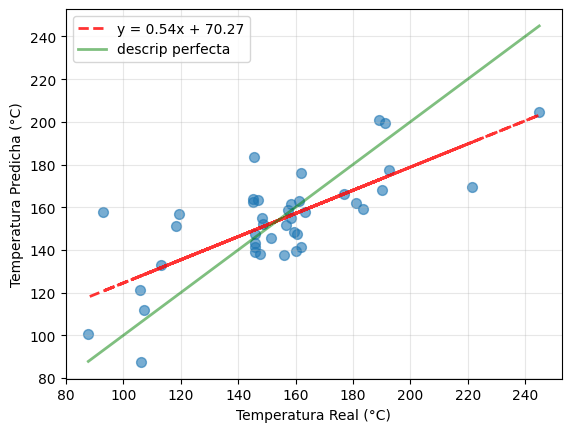

In [16]:
# graficar
y_pred = y_pred_train
y_real = y_train
    
# linea de regresión para las predicciones
z = np.polyfit(y_real, y_pred, 1)
p = np.poly1d(z)
    
plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2, 
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
    
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta')
    
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Ejercicios

- Para la simulacion, intente distintas variaciones de sus datos simulados, dé una variacion informada (educada)
- Para la regresion lineal, pruebe varias combinaciones de variables objetivos
- Haga una regresion linea con las mismas variables, pero solo usando datos originales (sin simulacion)
- Compare sus resultados de los dos puntos anteriores
- Esta es el primer contacto de como simular datos apartir de una base de datos chica, vaya pensando como puede mejorar esta simulacion
